In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
Adani=pd.read_csv("data/ADANIENT_minute.csv")
Adani.columns=Adani.columns.str.strip()

In [37]:
Adani['dif']=Adani['close']-Adani['close'].shift(1)
Adani['dir']=np.where(Adani['dif']>0,1,0)
Adani.dropna(inplace=True)

In [38]:
cost_per_side=0.0002
def process(dt):
    Mu2=abs(Adani['dif']).rolling(window=dt-1).mean().shift(1)
    Mu2.dropna(inplace=True)
    totdif=(Adani['dif'].rolling(window=dt-1).mean()).shift(1)*(dt-1)
    totdif.dropna(inplace=True)
    Mu1=Adani['dir'].rolling(window=dt-1).mean().shift(1)
    Mu1.dropna(inplace=True)
    Sigma1=Adani['dir'].rolling(window=dt-1).std().shift(1)
    Sigma1.dropna(inplace=True)
    moves=[]
    for x in range(0,dt+2):
        moves.append(0)
    moves.append(0)
    for x in range(dt+1,92671):
        mu1=Mu1.loc[x]
        mu2=Mu2.loc[x]
        sigma1=Sigma1.loc[x]
        w=totdif[x]
        p=(2*dt*dt+(2*w*dt)/mu2+mu1/(sigma1*sigma1))/(4*dt*dt+1/(sigma1*sigma1))
        if(p>0.5):
            moves.append(1)
        else:
            moves.append(0)
    loggain=[]
    for x in range(dt+1,92672):
        cost=abs(moves[x-1]-moves[x])*cost_per_side
        loggain.append(moves[x]*np.log(Adani['close'].iloc[x+1]/Adani['close'].iloc[x])-cost)
    logreturns=np.log(Adani['close']/Adani['close'].shift(1))
    logreturns.dropna(inplace=True)
    sharperatio=np.sqrt(94500)*(np.mean(loggain)/np.std(loggain))
    return(sharperatio)

sharperatios=[]
maxratio=0
maxdt=3
for x in range(89,376):
    ratio=process(x)
    if(ratio>maxratio):
        maxratio=ratio
        maxdt=x
    sharperatios.append(ratio)
    print(x)
    if(x%10==0):
        print("maxratio uptil "+str(x)+" trials = "+str(maxratio)+"at dt= "+str(maxdt))

89
90
maxratio uptil 90 trials = 0.05411079183534089at dt= 90
91
92
93
94
95
96
97
98
99
100
maxratio uptil 100 trials = 0.6467067381866279at dt= 100
101
102
103
104
105
106
107
108
109
110
maxratio uptil 110 trials = 0.6467067381866279at dt= 100
111
112
113
114
115
116
117
118
119
120
maxratio uptil 120 trials = 0.8915575622554112at dt= 114
121
122
123
124
125
126
127
128
129
130
maxratio uptil 130 trials = 1.3170935901342613at dt= 129
131
132
133
134
135
136
137
138
139
140
maxratio uptil 140 trials = 1.3170935901342613at dt= 129
141
142
143
144
145
146
147
148
149
150
maxratio uptil 150 trials = 1.3170935901342613at dt= 129
151
152
153
154
155
156
157
158
159
160
maxratio uptil 160 trials = 1.3170935901342613at dt= 129
161
162
163
164
165
166
167
168
169
170
maxratio uptil 170 trials = 1.3170935901342613at dt= 129
171
172
173
174
175
176
177
178
179
180
maxratio uptil 180 trials = 1.3170935901342613at dt= 129
181
182
183
184
185
186
187
188
189
190
maxratio uptil 190 trials = 1.3170

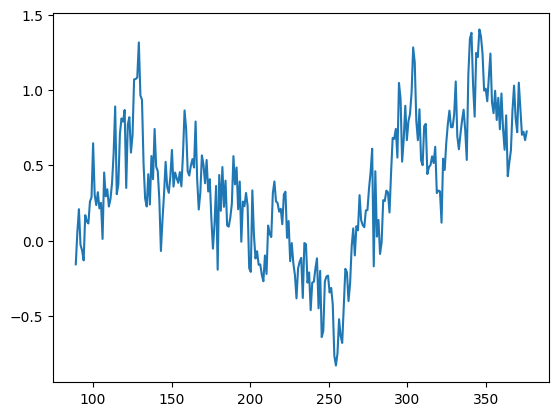

In [39]:
plt.plot(np.linspace(89,376,287),sharperatios)
plt.show()

In [40]:
print("maxratio= "+str(maxratio)+"at dt= "+str(maxdt))

maxratio= 1.403341090984995at dt= 345
